In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df = pd.read_csv("Housing.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
df.shape

(545, 13)

In [5]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [7]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [10]:
target = "price"

print("Target Variable:", target)

Target Variable: price


# Task 1: Dataset Inspection & Understanding

## Dataset Overview

The Housing Prices Dataset contains information about residential properties and their selling prices.

### Number of Rows and Columns

- Rows: 545
- Columns: 13

### Target Variable

The target variable is:

- **price**

Since price is a continuous numerical variable, this project is a **Supervised Machine Learning Regression Problem**.

---

## Feature Description

| Feature | Description |
|----------|-------------|
| area | Total area of the house |
| bedrooms | Number of bedrooms |
| bathrooms | Number of bathrooms |
| stories | Number of floors/stories |
| mainroad | Connected to main road |
| guestroom | Presence of guest room |
| basement | Presence of basement |
| hotwaterheating | Availability of hot water heating |
| airconditioning | Availability of air conditioning |
| parking | Number of parking spaces |
| prefarea | Located in preferred area |
| furnishingstatus | Furnishing condition |
| price | House selling price (Target Variable) |

---

## Data Types

### Numerical Features

- price
- area
- bedrooms
- bathrooms
- stories
- parking

### Categorical Features

- mainroad
- guestroom
- basement
- hotwaterheating
- airconditioning
- prefarea
- furnishingstatus

---

## Missing Value Analysis

The dataset contains:

- 0 missing values

No imputation is required.

---

## Duplicate Record Analysis

The dataset contains:

- 0 duplicate records

No duplicate removal is required.

---

## Data Quality Assessment

The dataset is clean and suitable for machine learning because:

- No missing values exist.
- No duplicate records exist.
- Data types are appropriate.
- Features are relevant to house price prediction.

---

## Features Expected to Influence House Prices

Based on domain knowledge, the following features are expected to significantly influence house prices:

- Area
- Number of bathrooms
- Number of bedrooms
- Number of stories
- Parking availability
- Air conditioning
- Preferred area
- Furnishing status

These assumptions will be validated during Exploratory Data Analysis (EDA).

# Task 2: Data Cleaning & Preprocessing

## Preprocessing Plan

Before building machine learning models, the dataset must be prepared for analysis.

The following preprocessing steps will be performed:

1. Verify missing values.
2. Verify duplicate records.
3. Encode categorical variables into numerical format.
4. Separate features and target variable.
5. Validate the transformed dataset.

### Missing Value Treatment

No missing values were found; therefore, no imputation is required.

### Duplicate Removal

No duplicate records were found; therefore, no rows need to be removed.

### Categorical Encoding

Machine learning algorithms cannot directly process text values.

The following categorical features will be encoded:

- mainroad
- guestroom
- basement
- hotwaterheating
- airconditioning
- prefarea
- furnishingstatus

One-Hot Encoding will be used to convert categorical variables into numerical format.

### Feature Selection

The target variable is:

- price

All remaining variables will be used as predictive features.

### Data Validation

After encoding:

- All features must be numerical.
- The target variable must remain unchanged.
- Dataset dimensions should be verified.

In [11]:
df_clean = df.copy()

print("Dataset copy created successfully")

Dataset copy created successfully


In [12]:
categorical_cols = df_clean.select_dtypes(include="object").columns

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [13]:
df_encoded = pd.get_dummies(
    df_clean,
    drop_first=True
)

df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [14]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    b

## Encoding Results

Categorical variables were transformed using One-Hot Encoding.

### Why Encoding Was Required

Machine learning algorithms require numerical input features.

The following categorical variables were encoded:

- mainroad
- guestroom
- basement
- hotwaterheating
- airconditioning
- prefarea
- furnishingstatus

### Outcome

- All features are now represented numerically.
- No information was lost during transformation.
- The target variable remained unchanged.
- The dataset is now ready for Exploratory Data Analysis and model building.

# Task 3: Exploratory Data Analysis (EDA)

The objective of EDA is to identify patterns, relationships, trends, and business insights hidden within the dataset.

The following analyses will be performed:

1. House Price Distribution
2. Correlation Analysis
3. Relationship between Area and Price
4. Feature Importance Investigation
5. Business Insight Extraction

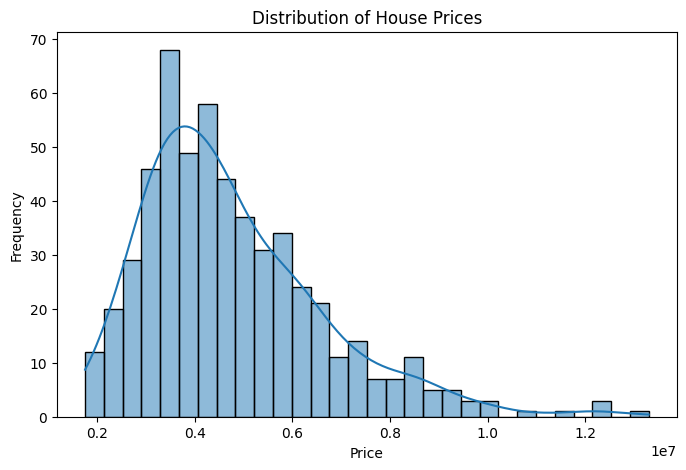

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["price"],
    bins=30,
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig("charts/price_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

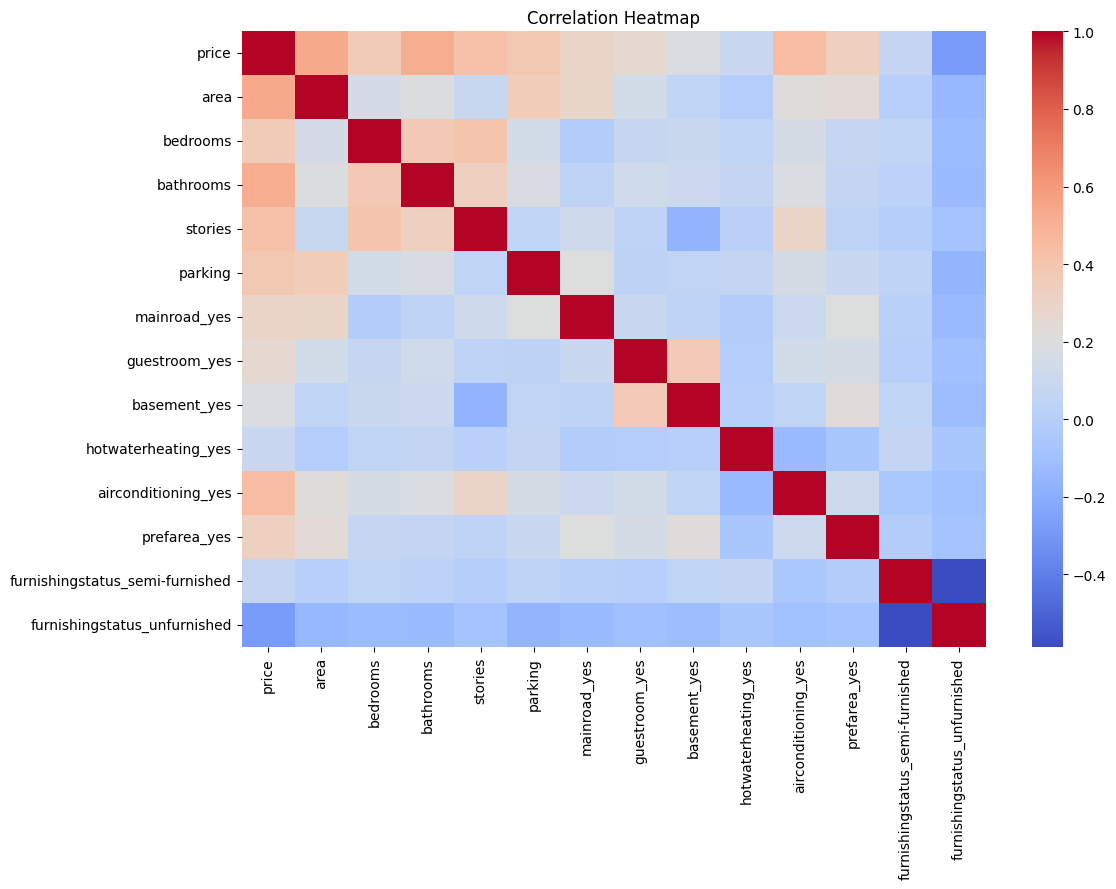

In [18]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_encoded.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.savefig("charts/correlation_heatmap.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [19]:
corr_with_price = (
    df_encoded.corr()["price"]
    .sort_values(ascending=False)
)

corr_with_price

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
guestroom_yes                      0.255517
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64

## EDA Findings

### House Price Distribution

The distribution of house prices is positively skewed (right-skewed).

Observations:

- Most houses are concentrated in the lower and middle price ranges.
- A small number of houses have exceptionally high prices.
- High-priced properties create a long right tail in the distribution.

Business Interpretation:

The housing market contains a small premium segment of luxury properties, while the majority of properties belong to affordable and mid-range categories.

---

### Correlation Analysis

The strongest positive correlations with house price are:

| Feature | Correlation |
|----------|------------|
| Area | 0.536 |
| Bathrooms | 0.518 |
| Air Conditioning | 0.453 |
| Stories | 0.421 |
| Parking | 0.384 |

The strongest negative correlation is:

| Feature | Correlation |
|----------|------------|
| Furnishing Status (Unfurnished) | -0.281 |

Business Interpretation:

Larger houses with more bathrooms, multiple stories, parking spaces, and air conditioning generally command higher prices.

Unfurnished houses tend to have lower market values compared to furnished properties.

---

### Key Insights

1. Area is the most influential feature.
2. Bathrooms contribute significantly to property value.
3. Air conditioning increases property desirability.
4. Parking availability positively impacts selling price.
5. Preferred locations increase house values.
6. Unfurnished houses generally sell for lower prices.

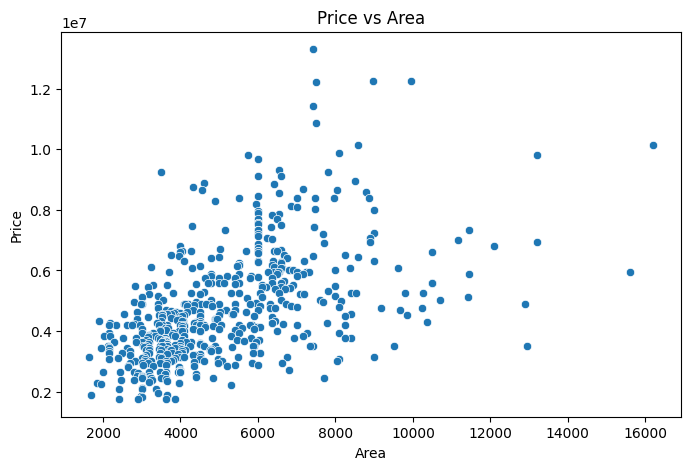

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["area"],
    y=df["price"]
)

plt.title("Price vs Area")
plt.xlabel("Area")
plt.ylabel("Price")
plt.savefig("charts/area_vs_price.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

### Area vs Price Observation

A positive relationship exists between house area and price.

Observations:

- Larger properties generally have higher prices.
- Some variation exists due to other factors such as location, furnishing status, parking, and amenities.
- Area alone does not completely determine house value.

Business Interpretation:

Increasing usable living space is one of the strongest ways to increase property value.

In [22]:
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (436, 13)
Testing Set Shape: (109, 13)


In [23]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_pred)
)

lr_r2 = r2_score(
    y_test,
    lr_pred
)

print("Linear Regression Results")
print("--------------------------")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R²  :", lr_r2)

Linear Regression Results
--------------------------
MAE : 970043.4039201636
RMSE: 1324506.9600914388
R²  : 0.6529242642153184


In [24]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest Results")
print("--------------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Results
--------------------------
MAE : 1013968.579587156
RMSE: 1398115.6668385956
R²  : 0.6132752494107068


# Task 5: Model Evaluation

## Model Comparison

| Metric | Linear Regression | Random Forest |
|----------|----------|----------|
| MAE | 970,043 | 1,013,969 |
| RMSE | 1,324,507 | 1,398,116 |
| R² Score | 0.653 | 0.613 |

## Evaluation Summary

The Linear Regression model achieved the best overall performance.

Observations:

- Lower prediction error compared to Random Forest.
- Better ability to explain variation in house prices.
- Simpler and easier to interpret.

The Random Forest model performed reasonably well but did not outperform Linear Regression on this dataset.

## Overfitting Assessment

No strong evidence of overfitting is observed from the available test-set performance.

Additional cross-validation would be recommended in a production environment.

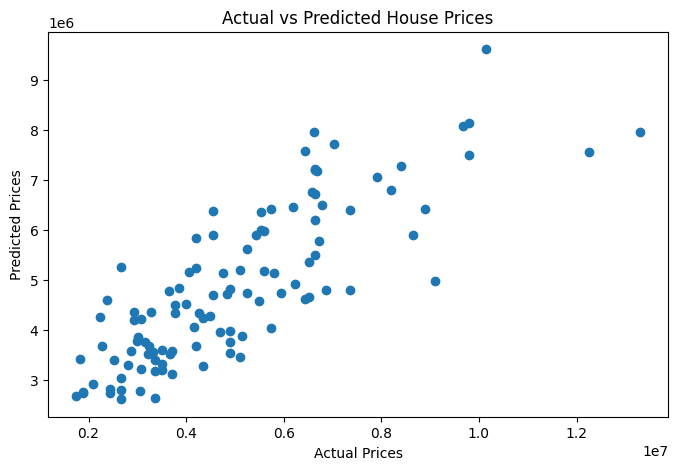

In [25]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    lr_pred
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.savefig("charts/Actual_area_vs_Predicted_house_price.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [26]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,area,0.468535
2,bathrooms,0.152554
9,airconditioning_yes,0.060238
4,parking,0.057273
3,stories,0.057064
1,bedrooms,0.047370
12,furnishingstatus_unfurnished,0.036972
7,basement_yes,0.032176
10,prefarea_yes,0.028432
8,hotwaterheating_yes,0.018305


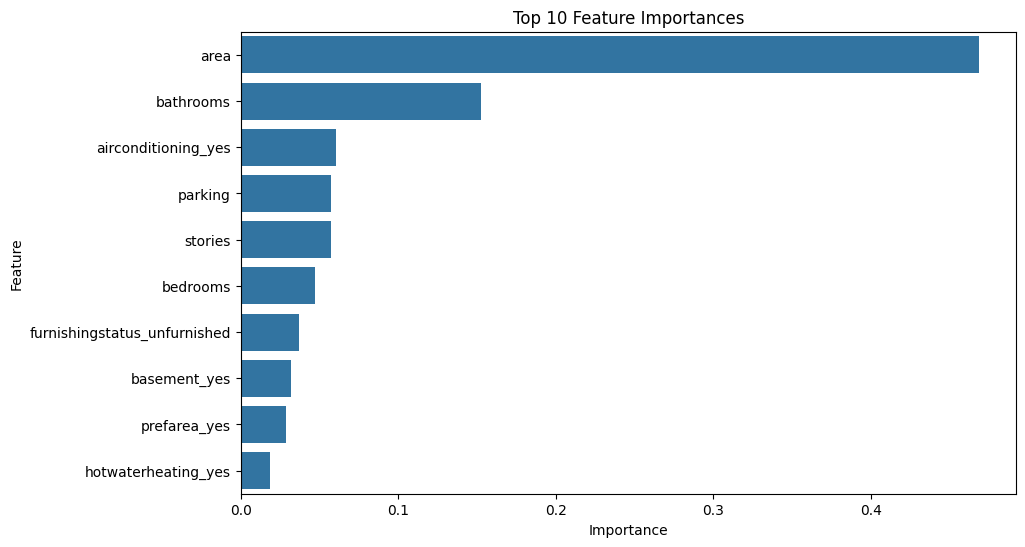

In [27]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances")

plt.savefig("Top 10 Feature Importances",
            bbox_inches="tight",
            dpi=300)

plt.show()

# Task 6: Business Insights

## Which Features Increase House Value Most?

The analysis indicates that the following features have the strongest positive influence on house prices:

1. Area
2. Bathrooms
3. Air Conditioning
4. Stories
5. Parking Availability
6. Preferred Area

## Which Features Have Lower Impact?

The following features appear to have weaker influence:

- Hot Water Heating
- Basement
- Guest Room

## Recommendations for Home Sellers

To maximize property value:

- Increase usable living area where possible.
- Improve interior quality and furnishing.
- Install air conditioning systems.
- Improve parking availability.
- Enhance bathroom quality and quantity.

## Recommendations for Buyers

Buyers should pay close attention to:

- Property area
- Number of bathrooms
- Parking facilities
- Location quality
- Air conditioning availability

## Recommendations for Real Estate Companies

- Focus marketing efforts on larger homes.
- Highlight air conditioning and parking features.
- Emphasize preferred-area properties.
- Use predictive analytics to estimate pricing accurately.

# Final Project Report

## Project Title

House Price Prediction Using Machine Learning

---

## Project Objective

The objective of this project was to analyze housing data and develop machine learning models capable of predicting house prices based on various property characteristics.

The project focused on:

- Understanding the dataset
- Cleaning and preprocessing data
- Performing Exploratory Data Analysis (EDA)
- Building predictive models
- Evaluating model performance
- Extracting business insights

---

## Dataset Overview

The Housing Prices Dataset contains information about residential properties and their selling prices.

Dataset Characteristics:

- Total Records: 545
- Total Features: 13
- Target Variable: Price

Features include:

- Area
- Bedrooms
- Bathrooms
- Stories
- Main Road Access
- Guest Room
- Basement
- Hot Water Heating
- Air Conditioning
- Parking
- Preferred Area
- Furnishing Status

---

## Data Cleaning and Preprocessing

The following preprocessing steps were performed:

### Missing Value Analysis

- Missing Values Found: 0
- No imputation was required.

### Duplicate Record Analysis

- Duplicate Records Found: 0
- No duplicate removal was required.

### Categorical Encoding

The following categorical variables were converted into numerical format using One-Hot Encoding:

- Main Road
- Guest Room
- Basement
- Hot Water Heating
- Air Conditioning
- Preferred Area
- Furnishing Status

After encoding, all features became suitable for machine learning algorithms.

---

## Exploratory Data Analysis (EDA)

### House Price Distribution

The distribution of house prices was positively skewed.

Observations:

- Most properties belong to low and medium price ranges.
- A small number of luxury properties create a long right tail.
- Outliers exist among high-priced properties.

### Correlation Analysis

Strong positive relationships were observed between price and:

- Area
- Bathrooms
- Air Conditioning
- Stories
- Parking

A negative relationship was observed for:

- Unfurnished properties

### Area vs Price Relationship

A positive relationship exists between area and house price.

Larger houses generally command higher market prices.

---

## Model Development

Two regression models were developed:

### 1. Linear Regression

Used as a baseline model for price prediction.

### 2. Random Forest Regressor

Used to capture potential non-linear relationships between variables.

---

## Model Evaluation

| Metric | Linear Regression | Random Forest |
|----------|----------|----------|
| MAE | 970,043 | 1,013,969 |
| RMSE | 1,324,507 | 1,398,116 |
| R² Score | 0.653 | 0.613 |

### Best Performing Model

Linear Regression achieved the highest R² score and lowest prediction errors.

Therefore, Linear Regression was selected as the final model.

---

## Feature Importance Analysis

Top factors influencing house prices:

1. Area
2. Bathrooms
3. Air Conditioning
4. Parking
5. Stories
6. Bedrooms

Lower impact features:

- Hot Water Heating
- Basement
- Guest Room

---

## Business Insights

### For Property Sellers

To maximize property value:

- Increase usable living area.
- Improve bathroom quality and quantity.
- Provide parking facilities.
- Install air conditioning.
- Improve furnishing quality.

### For Property Buyers

Important factors to evaluate:

- Property area
- Number of bathrooms
- Parking availability
- Location quality
- Air conditioning

### For Real Estate Companies

- Prioritize larger homes in marketing campaigns.
- Highlight premium amenities.
- Use predictive analytics for pricing strategies.
- Focus on preferred-area properties.

---

## Conclusion

This project successfully developed machine learning models for predicting house prices.

Key findings:

- Area is the strongest predictor of house price.
- Bathrooms, parking, and air conditioning significantly increase property value.
- Linear Regression outperformed Random Forest on this dataset.
- The developed model can assist buyers, sellers, and real estate companies in making data-driven pricing decisions.

The project demonstrates how machine learning can be applied to solve real-world business problems in the real estate domain.